# 7단계 로컬 운영 진입점
배치 → 저장 모델 추론 → 분포 변화 감지 → 원인 확인 후 후보 생성 → 분리 평가 → 교체/롤백.
기본 실행은 상태 조회만 합니다. 독립 평가 자료와 현장 기준이 없는 자동 운영은 시작하지 않습니다.
CLI의 각 명령과 같은 공통 구현을 사용합니다. 자세한 예시는 common/OPERATIONS_GUIDE.txt를 참고하세요.

In [1]:
from pathlib import Path
import sys
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'03.modeling').is_dir())
sys.path.insert(0,str(ROOT/'03.modeling/common'))
from governance_runtime import Operations
DATASET='rg3'
ops=Operations(DATASET)
ops.registry()

{'active_ocsvm': None,
 'fixed_if': 'if-7e69cab8fdd04a17',
 'history': [{'action': 'fix_if_reference',
   'version': 'if-7e69cab8fdd04a17',
   'at': '2026-10-02T01:43:12.412776+00:00'}],
 'active_models': {'if': 'if-7e69cab8fdd04a17'}}

## 명시적으로 수행할 작업
1. 초기 후보의 버전과 지정 사유를 확인한 후 `ops.initialize(version, reason)`.
2. `ops.ingest(frame, label_source="실제 출처", coordinates_confirmed=True)`.
3. 표본이 누적되면 드리프트가 계산됩니다. 생산 시간 미확인 자료로 시간 성능을 주장하지 않습니다.
4. 원인 확인 후 `ops.retrain(kind, batch_ids, drift_id, cause)`.
5. `ops.register_evaluation(frame, label_source)`로 학습과 별개인 평가 패턴을 예약.
6. `ops.evaluate(candidate, evaluation_id)` 결과와 분포 안내 확인.
7. 통과한 평가만 `ops.promote(assessment_id)`. 필요시 `ops.rollback(kind, reason)`.
수집 후 감지·안내 단계가 실패하면 수집은 유지됩니다. `ops.pending_batches()`로 확인하고 같은 batch_id로 다시 보내거나 `ops.resume(batch_id)`를 실행합니다. 다른 batch_id로 다시 보내지 않습니다.
비라벨은 추론·감지만 가능하고 재학습에는 쓰지 않습니다.
RG3의 구간 안내에는 참조·평가 관측 수, 위험 이력, Wilson 구간과 표본 부족 표시가 들어갑니다.

### 최근 배치 판단 결과 (읽기 전용)
CN7은 RF 검사 우선순위(상위 검사 비율), RG3는 판단 불확실 단계(높음·중간·낮음·판단 대기)를 보여줍니다. 판단 대기는 감지 표본이 모자라 아직 판단하지 않은 상태이며 낮음이 아닙니다. 불량 확률이 아닙니다.

In [ ]:
# 읽기 전용: 최근 배치의 판단 결과 확인 (변경 작업 없음)
import json
ledger=ops.state/'batch_ledger.json'
ids=json.loads(ledger.read_text(encoding='utf-8'))['batches'] if ledger.exists() else []
if not ids:
    print('수집된 배치 없음')
else:
    folder=ops.state/'batches'/ids[-1]
    for name in ['inspection_priority.txt','inspection_advice.txt']:   # CN7 검사 우선순위 / RG3 불확실 단계
        if (folder/name).exists():
            print(f'[{ids[-1]}] {name}');print('\n'.join((folder/name).read_text(encoding='utf-8').splitlines()[:25]))

## 결과보고서 v4 시각화

아래 셀만 실행하면 이 노트북에 해당하는 보고서 그림을 표시한다. 기존 학습·전처리·운영 셀을 다시 실행할 필요가 없다.
공통 생성 코드는 `reporting/visualizations.py`에 있다. 그림이 없으면 해당 코드를 먼저 실행한다.
고정 Test는 이미 관찰한 후속 평가이며, RF 연구 v1과 표준화 수정 후 v2를 구분한다.
시각화용 중앙값·IQR 변환은 표시 목적에 한정되며 모델 입력이나 기존 표준화 로직을 변경하지 않는다.


### RG3 실제 정책 규칙과 IF·무작위의 동일 예산 비교

고정 Test 대응 원본 N238·불량5 / 정책 함수 실제 호출·격리 폴더 / random_share0.5 / 1000회·seed42 / 수직선95% 변동 범위

정책 우선순위는 참조 범위 이탈·정보 부족과 ID 순서로 결정하였다. 평가 라벨은 대상 선정에 사용하지 않았다. 비율5·10·20%는 사전 예시이며 승인된 현장 정책이나 최적 예산이 아니다.

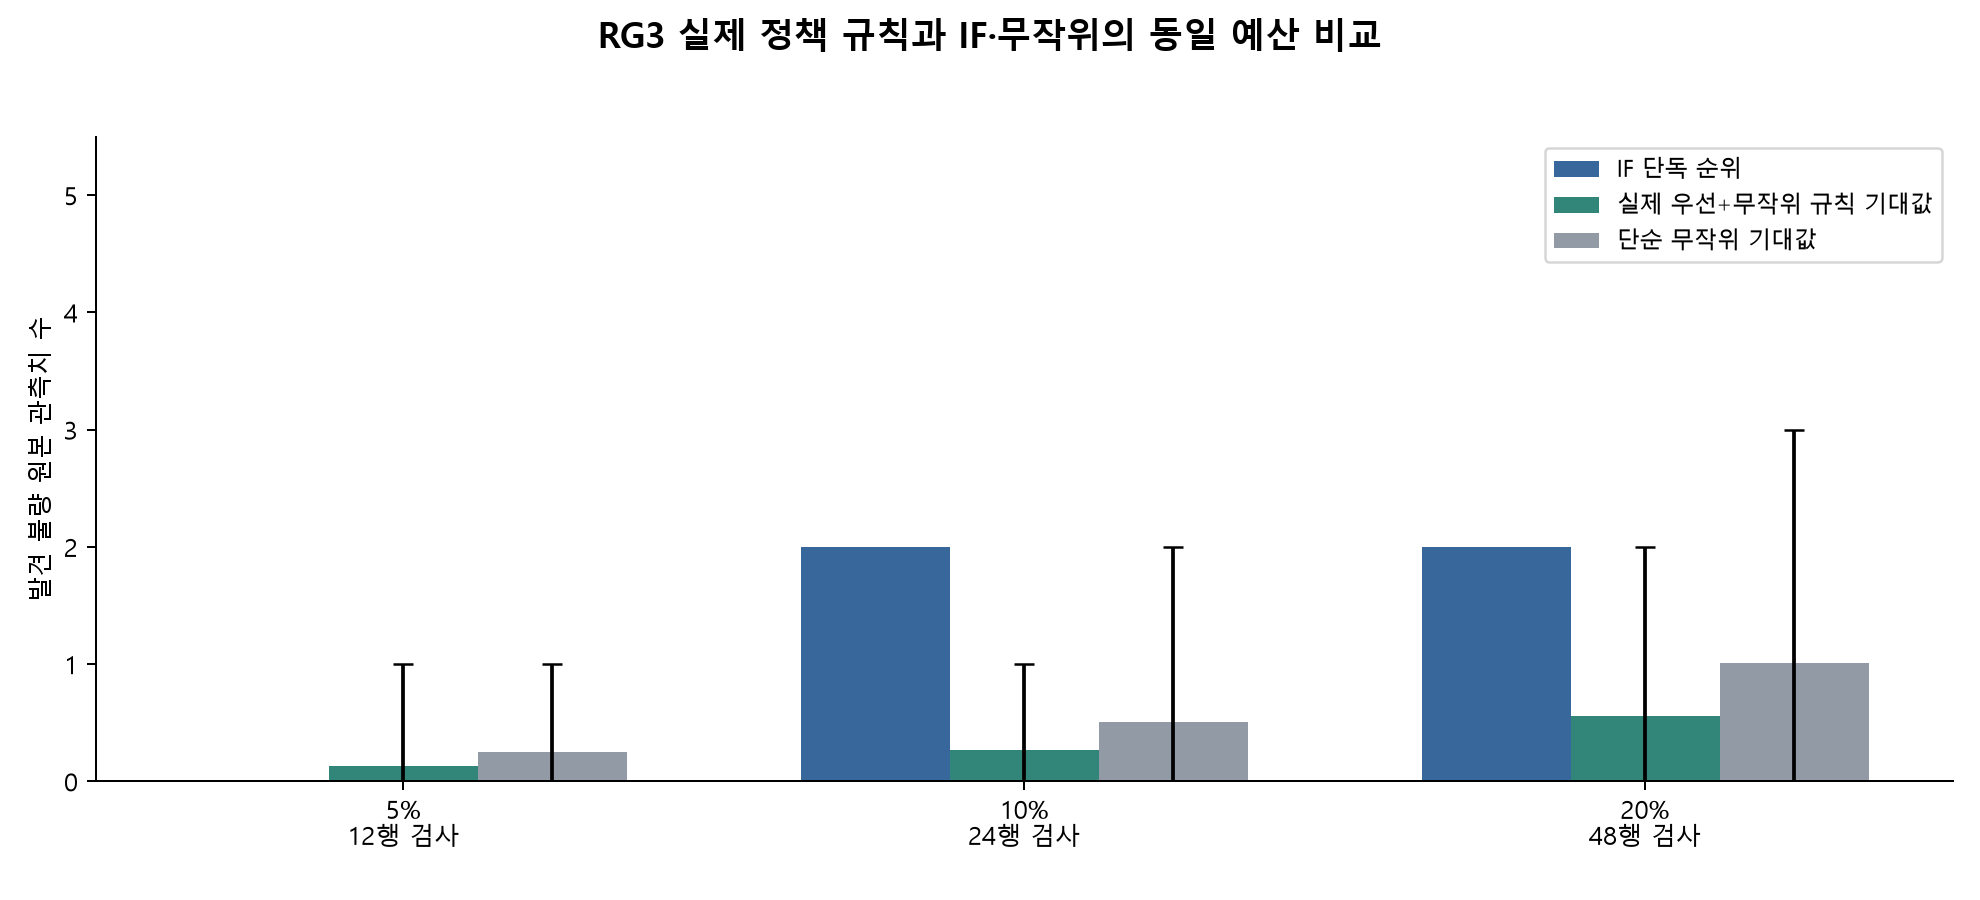

### 개발 정상 참조와 실제 비라벨 자료의 입력 분포

CN7 참조473·비라벨35239 / RG3 참조452·비라벨35941 / 제공 좌표 / 품질 라벨·생산시각 없음

실제 비라벨 분포 차이를 확인하였다. 두 자료의 최초 표준화 기준 정합이 확인되지 않아 현장 드리프트 또는 품질 악화로 확정하지 않았다.

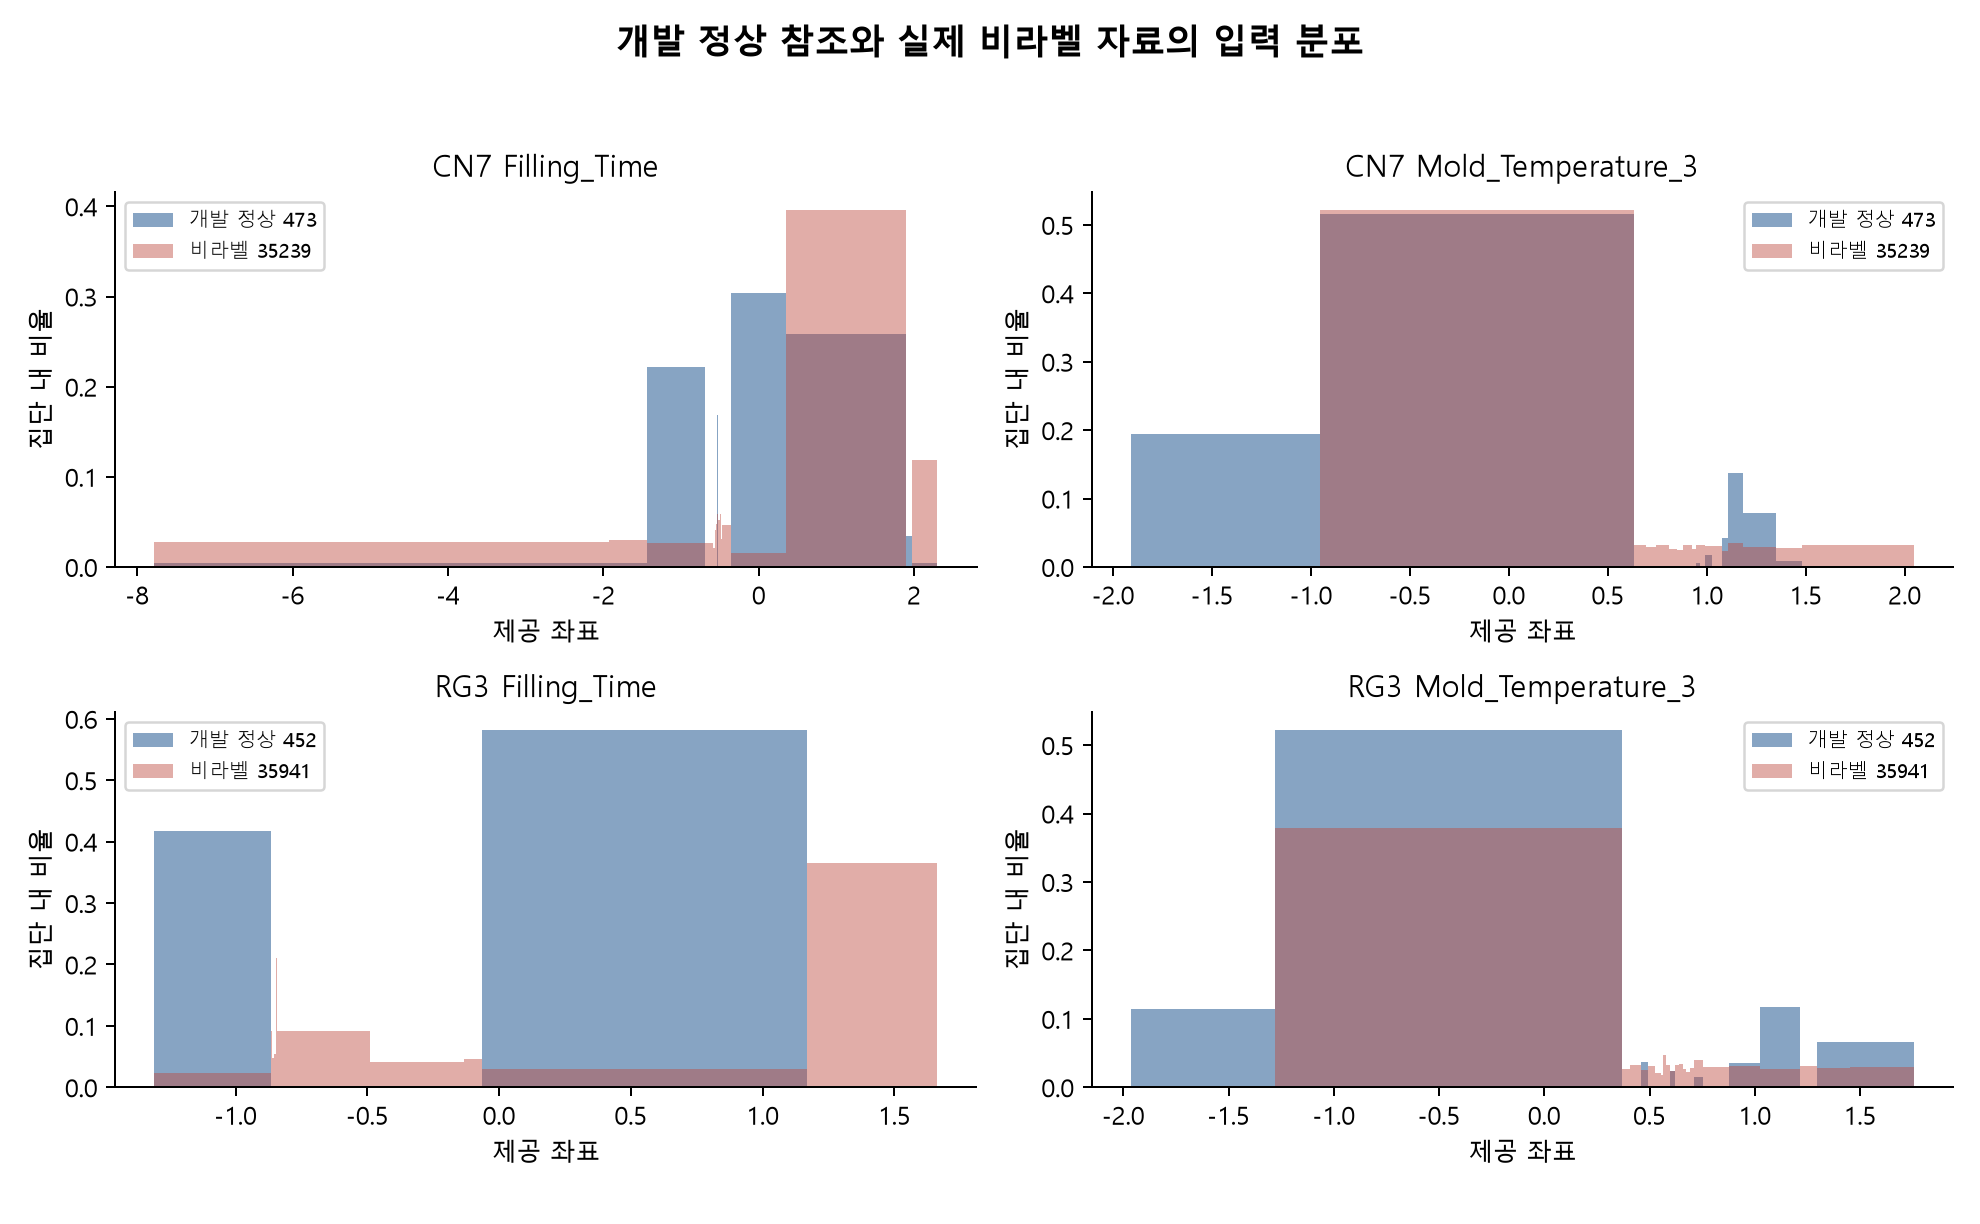

### 같은 IF 모델에서 참조·비라벨 점수 분포 비교

고정 IF CN7 if-a7a2fcba54e54d58·RG3 if-7e69cab8fdd04a17 / 비라벨 전수 / 모델·좌표 기준 고정

비라벨의 점수 이동은 같은 모델에서 비교하였다. 불량 라벨이 없어 점수 변화만으로 품질 악화나 재학습 효과를 판정할 수 없다.

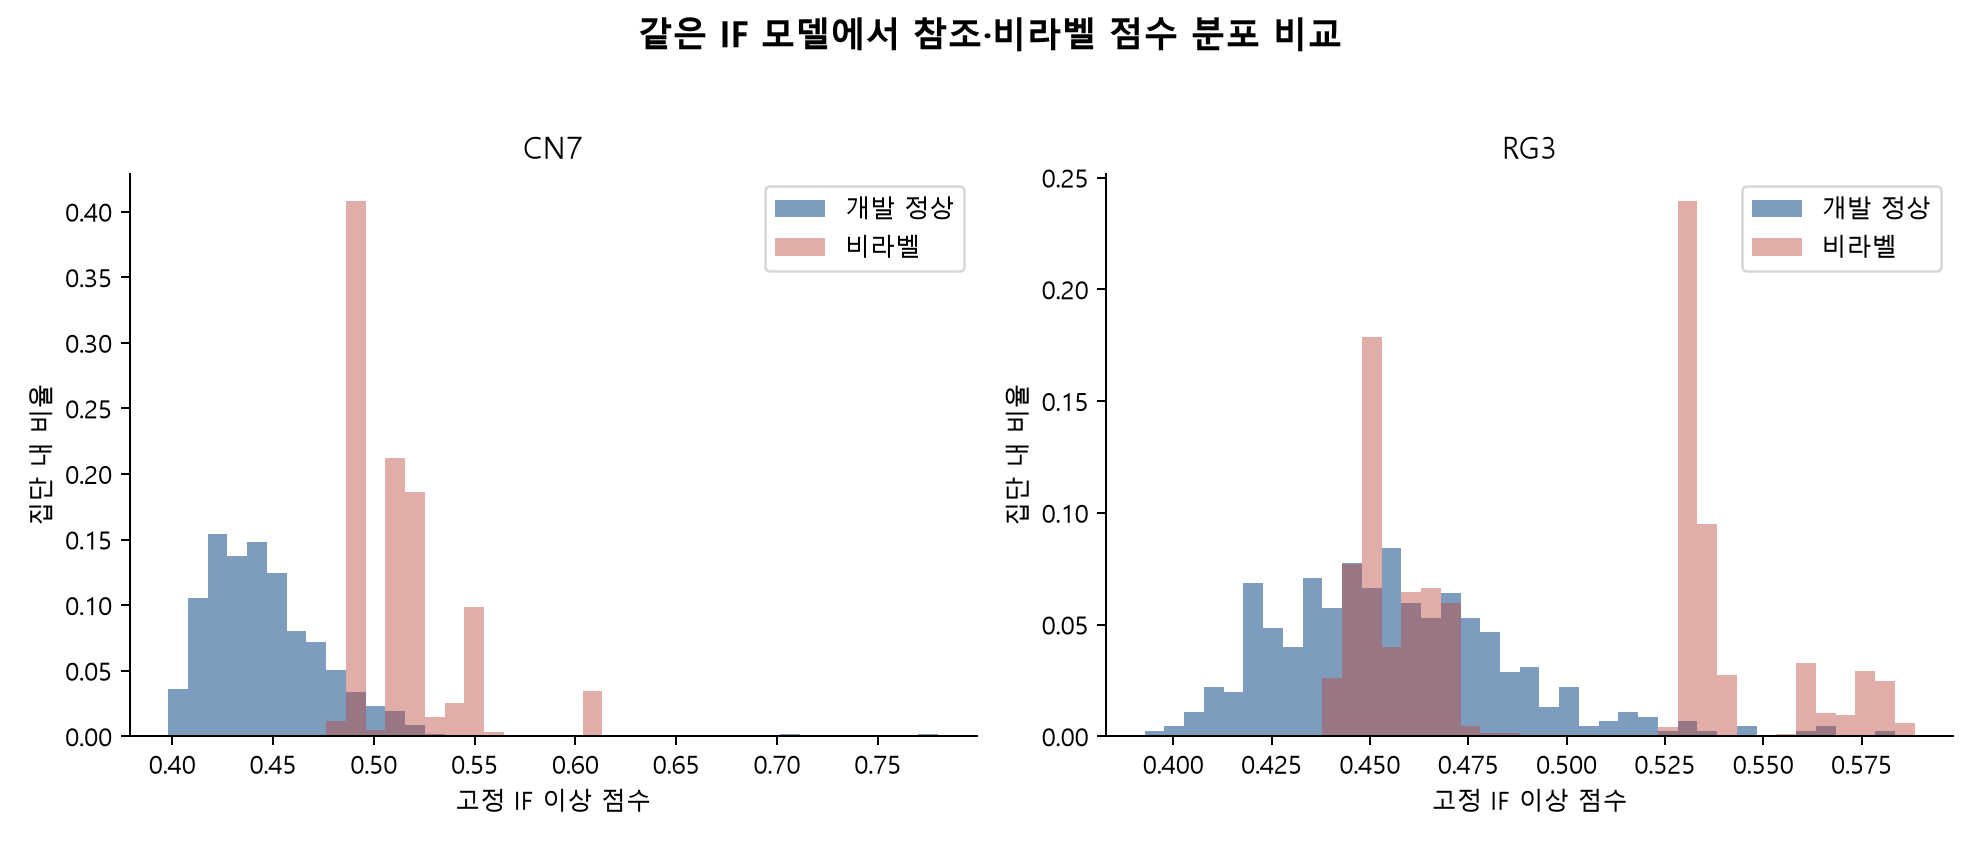

### 변화 감지부터 재학습·승격까지의 판단 절차

governance_runtime·workflow_runtime / 구현 절차도 / 독립 현장 재학습 전후 결과 없음

변화 감지는 재학습 승인 사유의 일부이다. 실제 독립 holdout의 기존·후보 성능 자료가 없으므로 개선·유지 사례를 실증 성과로 만들지 않았다.

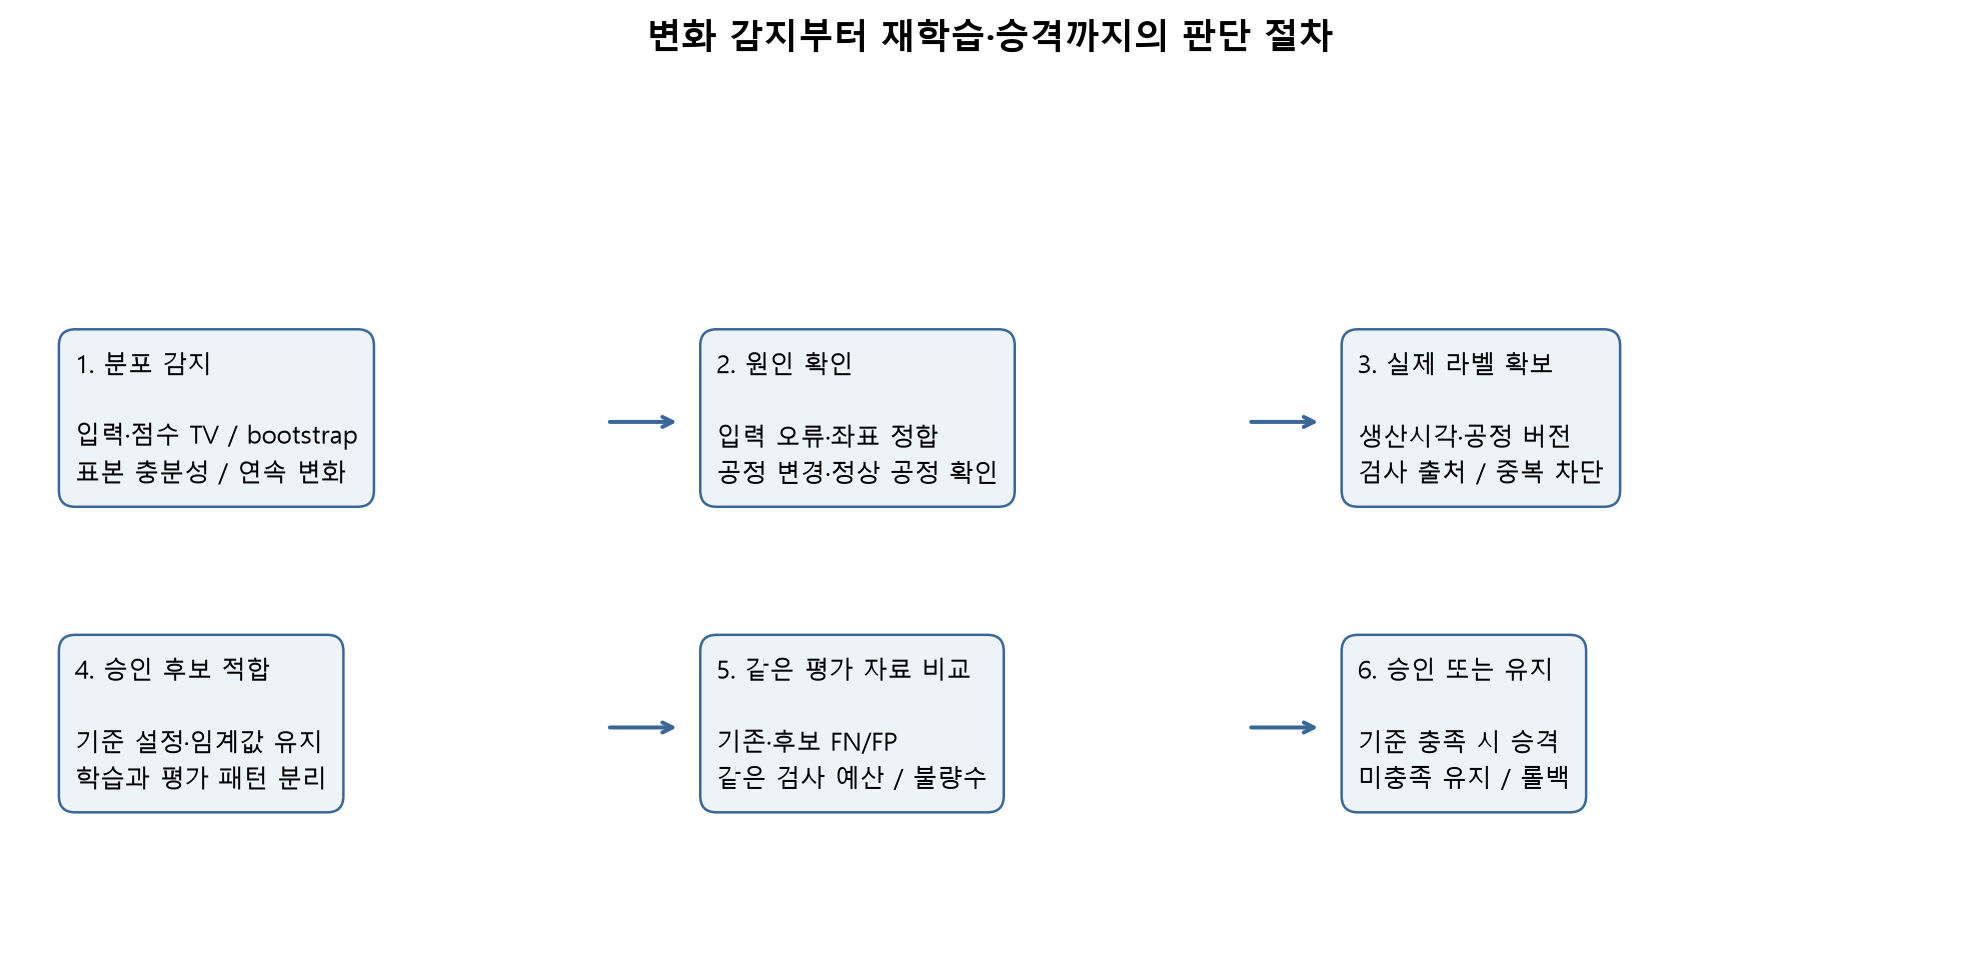

보고서 수록 그림: rg3_actual_policy_comparison, unlabeled_distribution_change, unlabeled_score_change, operations_ct_decision


In [4]:
# 보고서용 시각화: 기존 학습 셀을 실행하지 않고 저장 결과를 표시한다.
from pathlib import Path
import sys
_report_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "reporting/visualizations.py").is_file())
if str(_report_root) not in sys.path:
    sys.path.insert(0, str(_report_root))
from reporting.visualizations import show_notebook
_report_figure_ids = show_notebook('03.modeling/04_operations.ipynb')
print("보고서 수록 그림:", ", ".join(_report_figure_ids))
